In [ ]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#  Copyright 2025 The University of Manchester
#  Copyright 2025 Danmarks Tekniske Universitet
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:    Luke Lozenski (DTU)
#                   Nalin Gupta   (UKRI-STFC)
#                   Rasmia Kulan  (UKRI-STFC)
#                   Laura Murgatroyd (UKRI-STFC)

# NikonDataReader Demo

Note: this demo is a work in progress and was created for the purpose of demonstrating a contribution for the reader hackathon!

Here demo how to read in Nikon Data, perform FDK reconstruction, and perform model based image reconstruction utilizing a primal dual hybrid gradient.

The  NikonDataReader allows:

- Reading of geometry
- Reading of projections 
- Normalization based on the white level
- Reading in projections of interest
- Flipping the data 
- Reading of flat fields

## Data format: .xtekct file


## CIL Version

This notebook was developed using CIL v25.0.0

In [2]:
import cil
cil.version.version

'26.0.0'

## Dataset
The data is available from: https://zenodo.org/records/14996227. Specifically this notebook works with the data in `Nikon single mat metal 1000 acq.zip`, which can be downloaded from: https://zenodo.org/records/14996227/files/Nikon%20single%20mat%20metal%201000%20acq.zip

Update this filepath to where you have saved the dataset:

In [9]:
file_path = '/mnt/share/materials/CIL/Reader-Showcase/Nikon single mat metal/RUP_060225_XX_WMG_CCPIDATSETS_EZJB_2_1K.xtekct'

## Loading Geometry

In [10]:
from cil.utilities.display import show2D, show_geometry
from cil.io import NikonDataReader

In [11]:
reader = NikonDataReader(file_path)

We can call the `.get_geometry` command to load the geometry of the imaging system without loading the raw data files. 

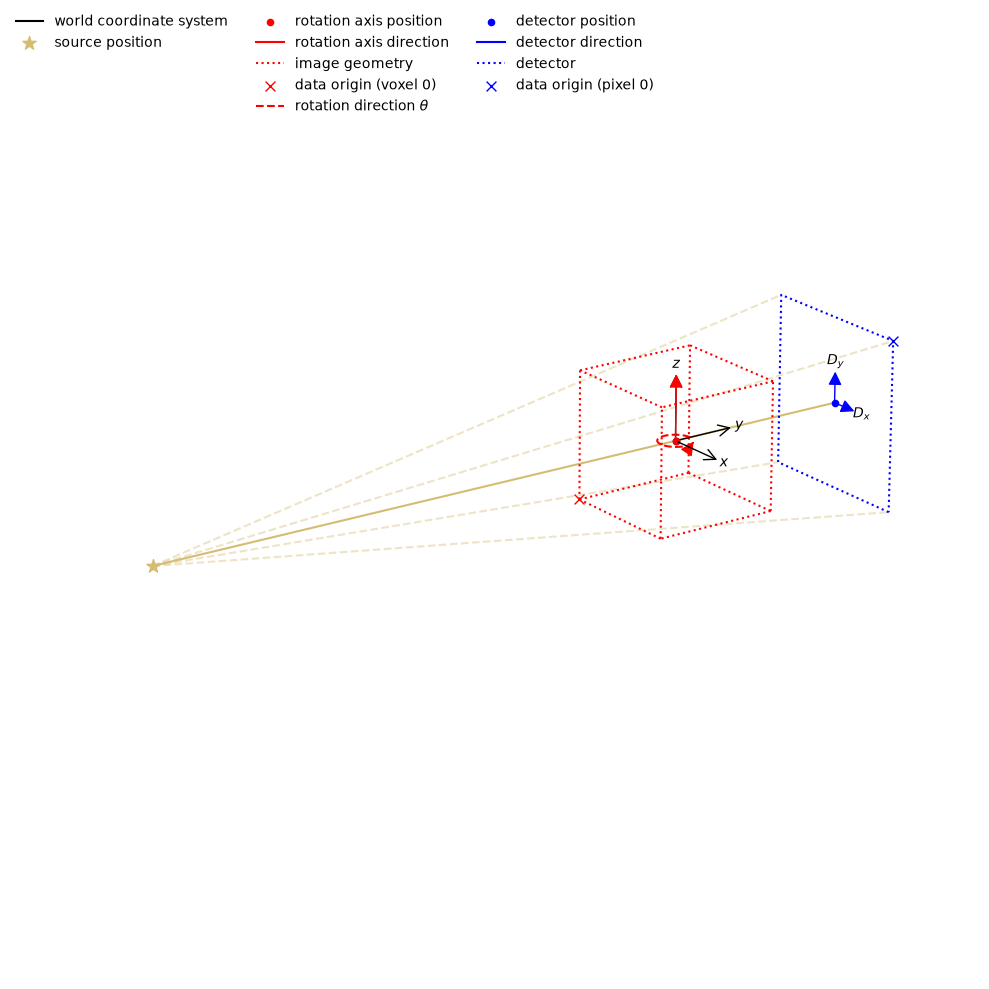

In [12]:
acq_geom = reader.get_geometry()
show_geometry(acq_geom)

In [13]:
print(acq_geom)

3D Cone-beam tomography
System configuration:
	Source position: [    0.  , -1337.05,     0.  ]
	Rotation axis position: [-0.,  0.,  0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [ -0.   , 442.934,   0.   ]
	Detector direction x: [1., 0., 0.]
	Detector direction y: [0., 0., 1.]
Panel configuration:
	Number of pixels: [ 999 1000]
	Pixel size: [0.4 0.4]
	Pixel origin: top-right
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1560
	Angles 0-9 in degrees: [180.     , 179.76923, 179.53847, 179.3077 , 179.07692, 178.84616,
 178.61539, 178.38461, 178.15384, 177.92308]
	Angles 1550-1559 in degrees: [-177.69226, -177.92303, -178.15381, -178.38458, -178.61533, -178.8461 ,
 -179.07687, -179.30765, -179.53842, -179.7692 ]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


## Loading Projections, Cropped Subsets of Interest, and Data Manipulation

To load and display a specific projection of interest we can use the show2D command with the specified projection of interest specified

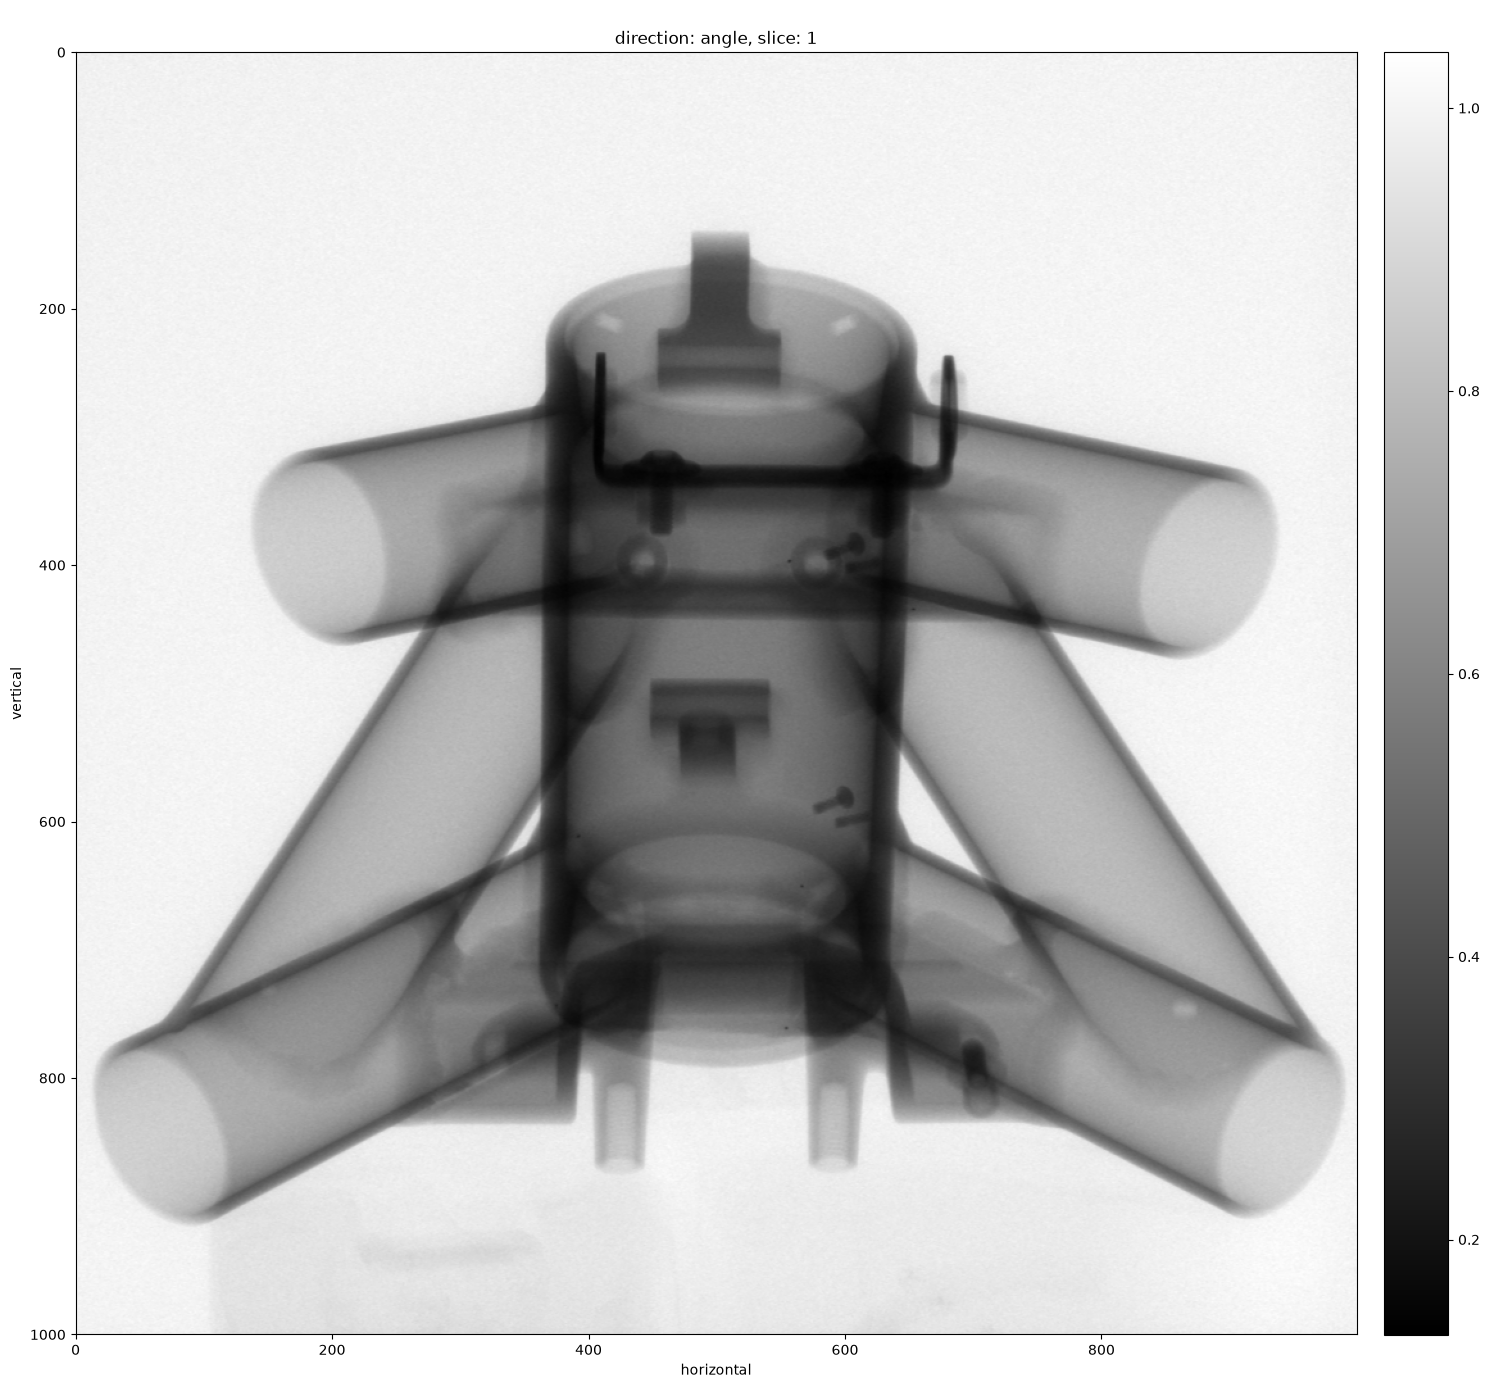

In [14]:
data = reader.read()
show2D(data, slice_list=('angle', 1), origin='upper-left')

By default the NikonDataReader argument `normalise` is `True`, which means all projections are loaded and normalised by the detector white level, which is stored in the .xtekct file as WhiteLevel. If you want to load the data without normalisation, specify `normalise=False`

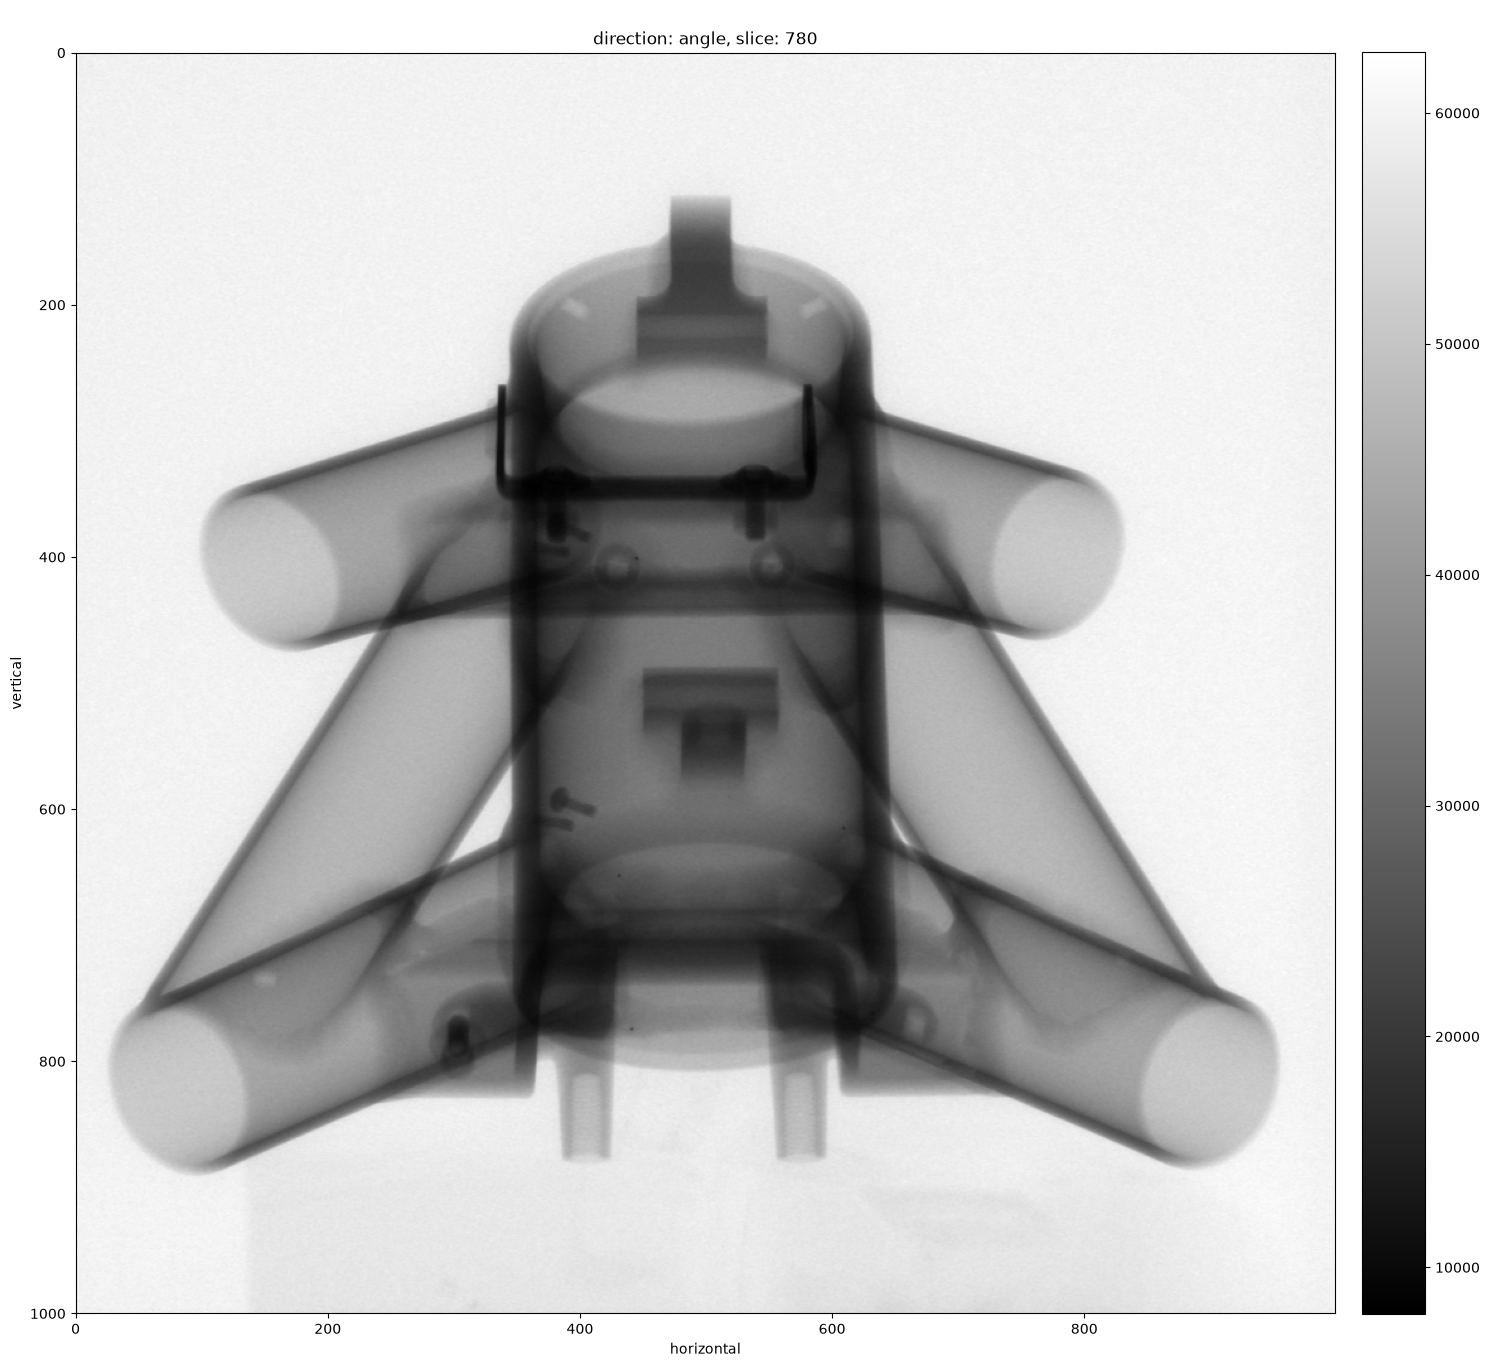

In [15]:
reader_norm_false = NikonDataReader(file_name=file_path, normalise=False)
data_unnormed = reader_norm_false.read()
show2D(data_unnormed, origin='upper-left')
del data_unnormed


Use the `roi` argument to load a subset of the data. `roi` should be passed as a dictionary e.g. `{'axis_labels_1': (start, end, step),'axis_labels_2': (start, end, step)}` with axis labels that describe the data dimension labels.

To load a cropped subset of the data, change the start and end values. `'axis_label': -1` is a shortcut to load all elements along the axis.



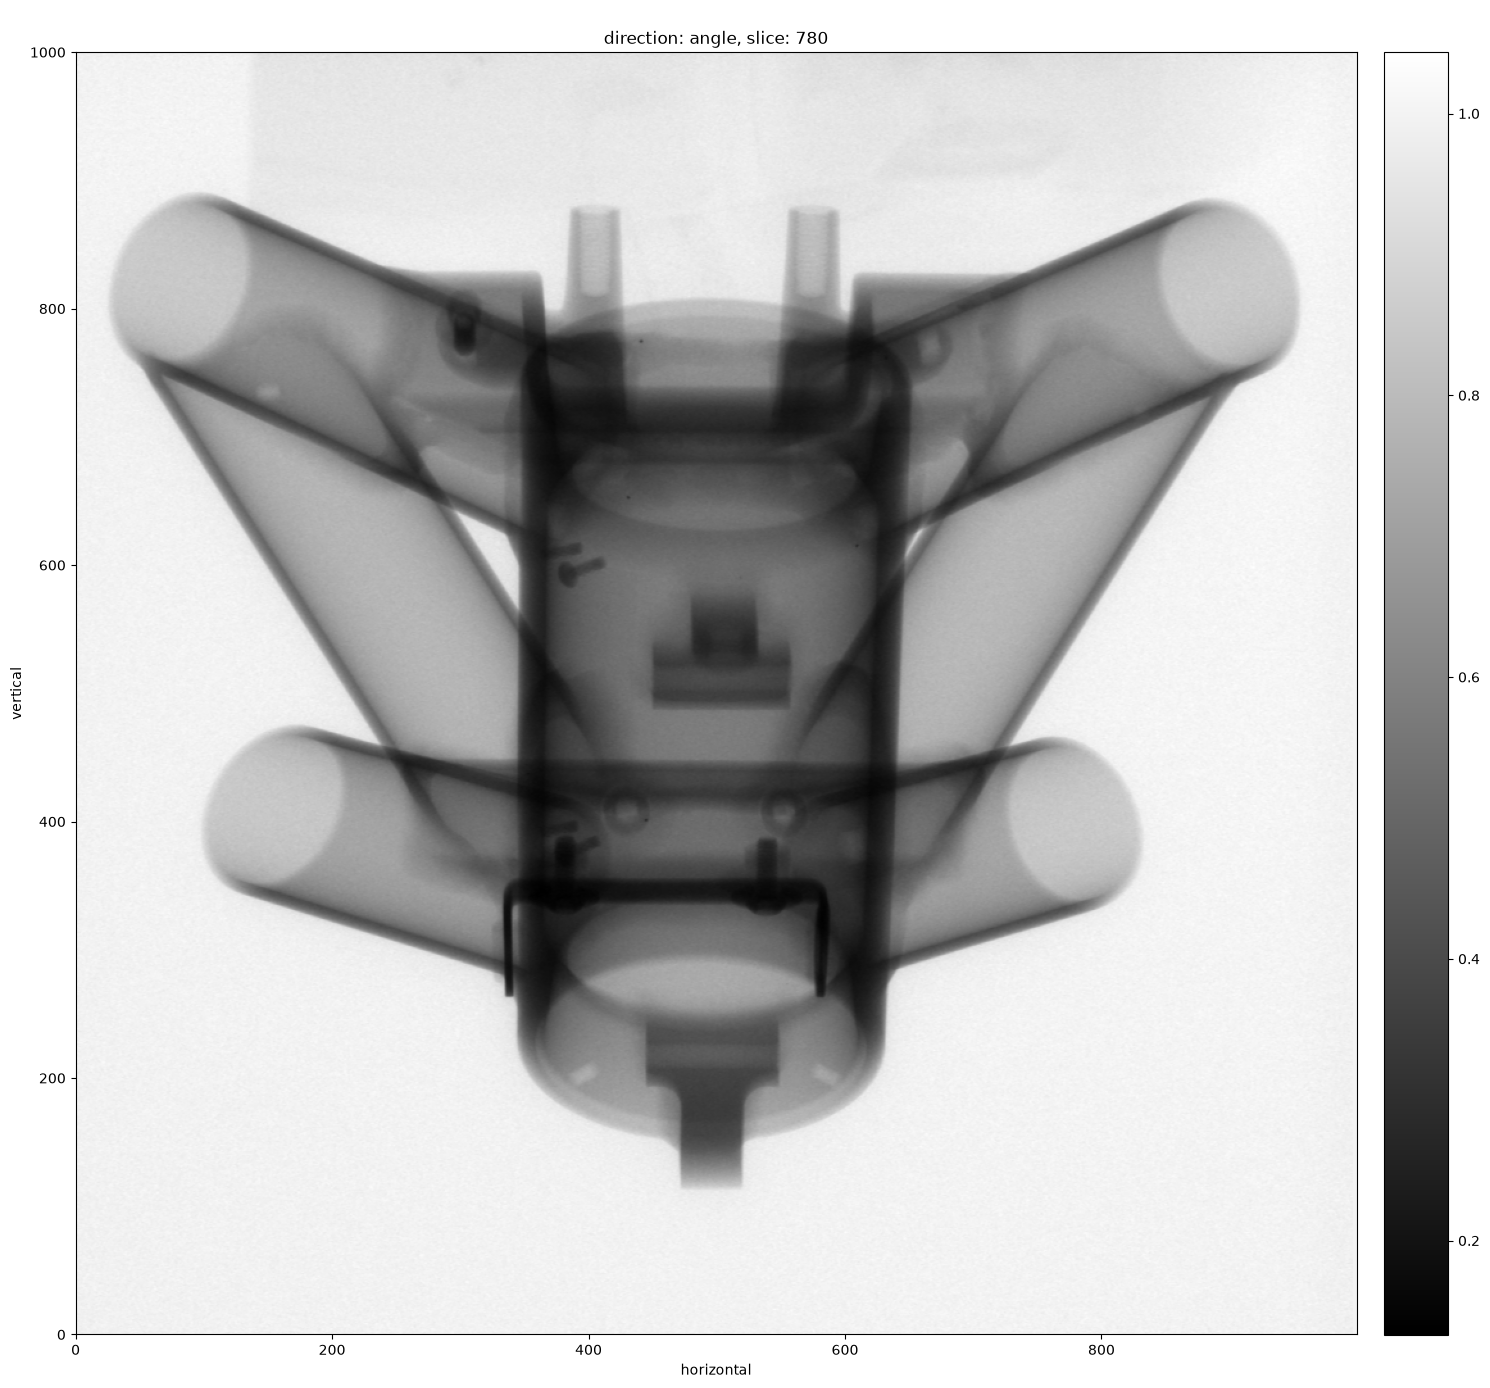

In [16]:
roi = {'horizontal':(120, 870, 1), 'vertical':-1}
reader_roi = NikonDataReader(file_name=file_path, roi=roi)
data_roi = reader.read()
show2D(data_roi)
del data_roi


To load a binned subset of the data, change the step value. Here we use different binning for the horizontal and vertical dimensions which results in a different aspect ratio

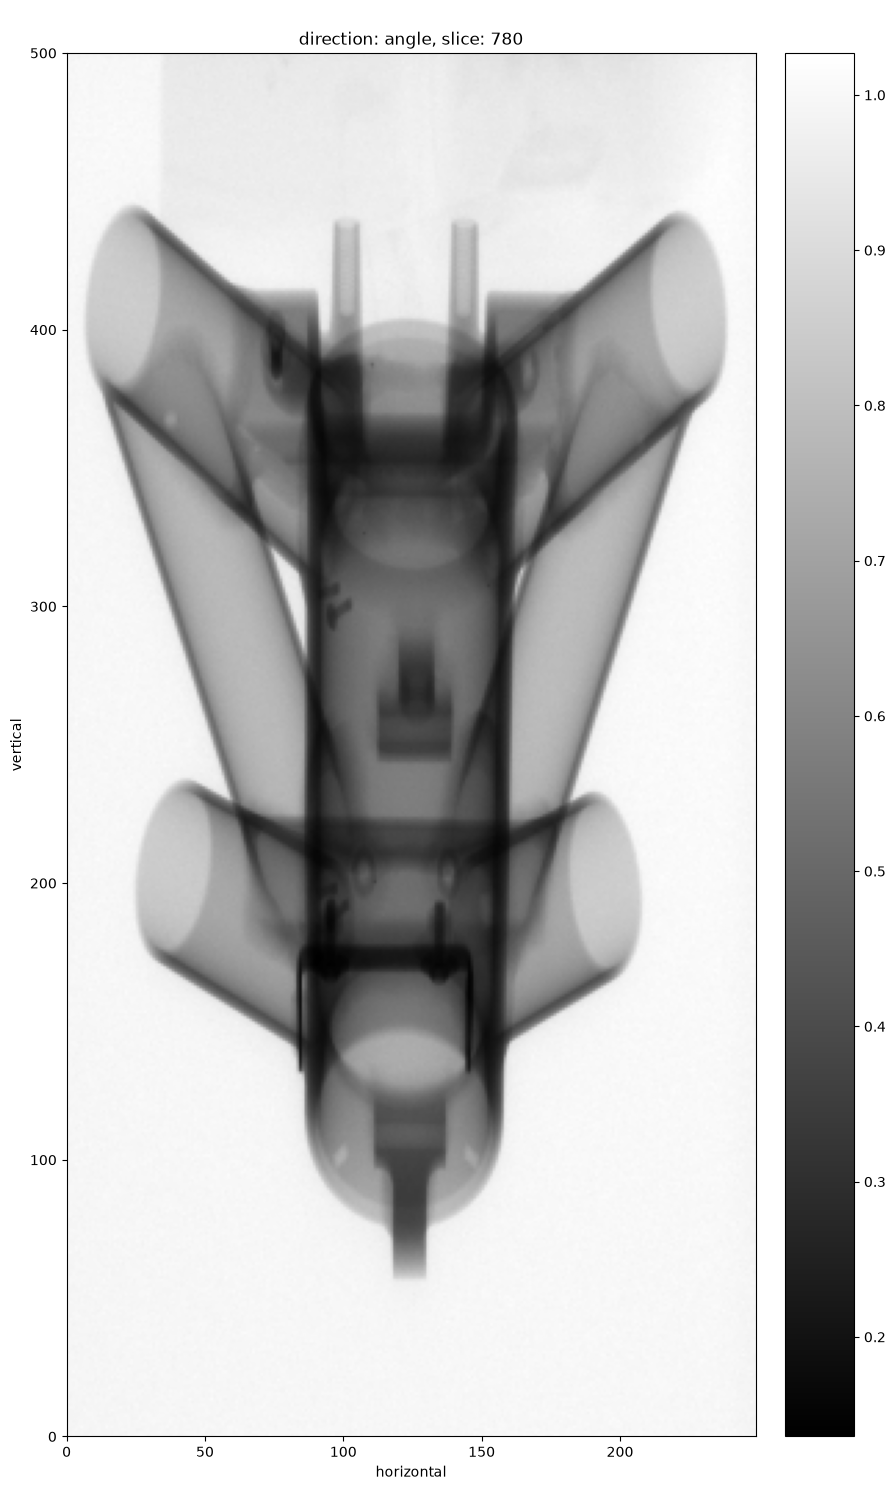

In [27]:
roi = {'horizontal':(None, None, 4), 'vertical':(None, None, 2)}
reader_binned = NikonDataReader(file_name=file_path, roi=roi)
data_binned = reader_binned.read()
show2D(data_binned)
del data_binned

We can also use the argument `fliplr=True` to flip all projections in the vertical axis. If we enable this option we see that the projection is flipped in the left-right direction

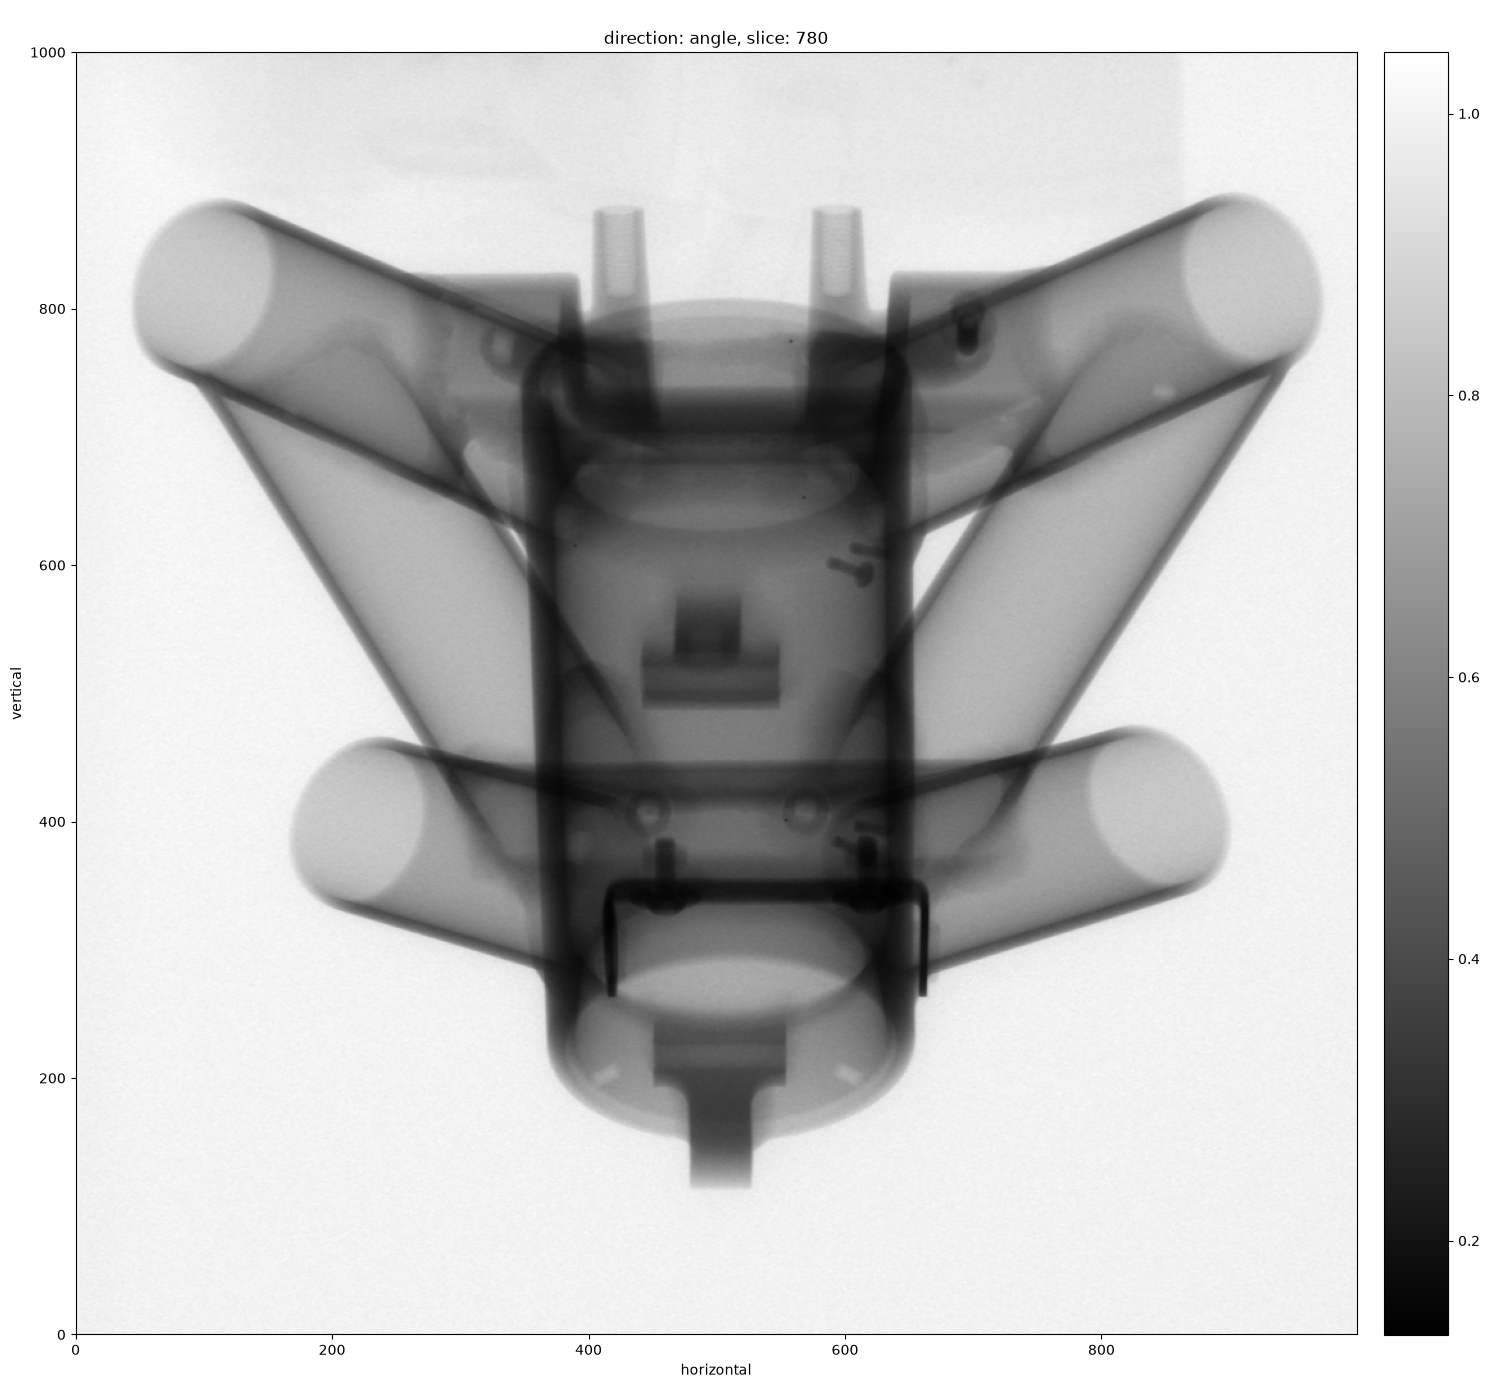

In [28]:
reader_fliplr = NikonDataReader(file_name=file_path, fliplr=True)
data_fliplr = reader_fliplr.read()
show2D(data_fliplr)
del data_fliplr

# Pre-processing and Reconstruction

Here we load the data, perform conversion from transimission to absorption, and define the image and acquisiton geometries from the data loader.

In [ ]:
from cil.plugins.tigre import FBP
from cil.processors import TransmissionAbsorptionConverter

data_exp = TransmissionAbsorptionConverter()(data)
data_exp.reorder('tigre')
acq_geom = reader.get_geometry()
img_geom = acq_geom.get_ImageGeometry()

/home/lhe97136/miniconda3/envs/cil_26_demos/lib/python3.12/site-packages/tigre/utilities/common_geometry.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.spatial.transform import Rotation


Then we can perform the FDK reconstruction

In [20]:
fdk = FBP(img_geom, acq_geom)
fdk.set_input(data_exp)
fdk_recon = fdk.get_output()

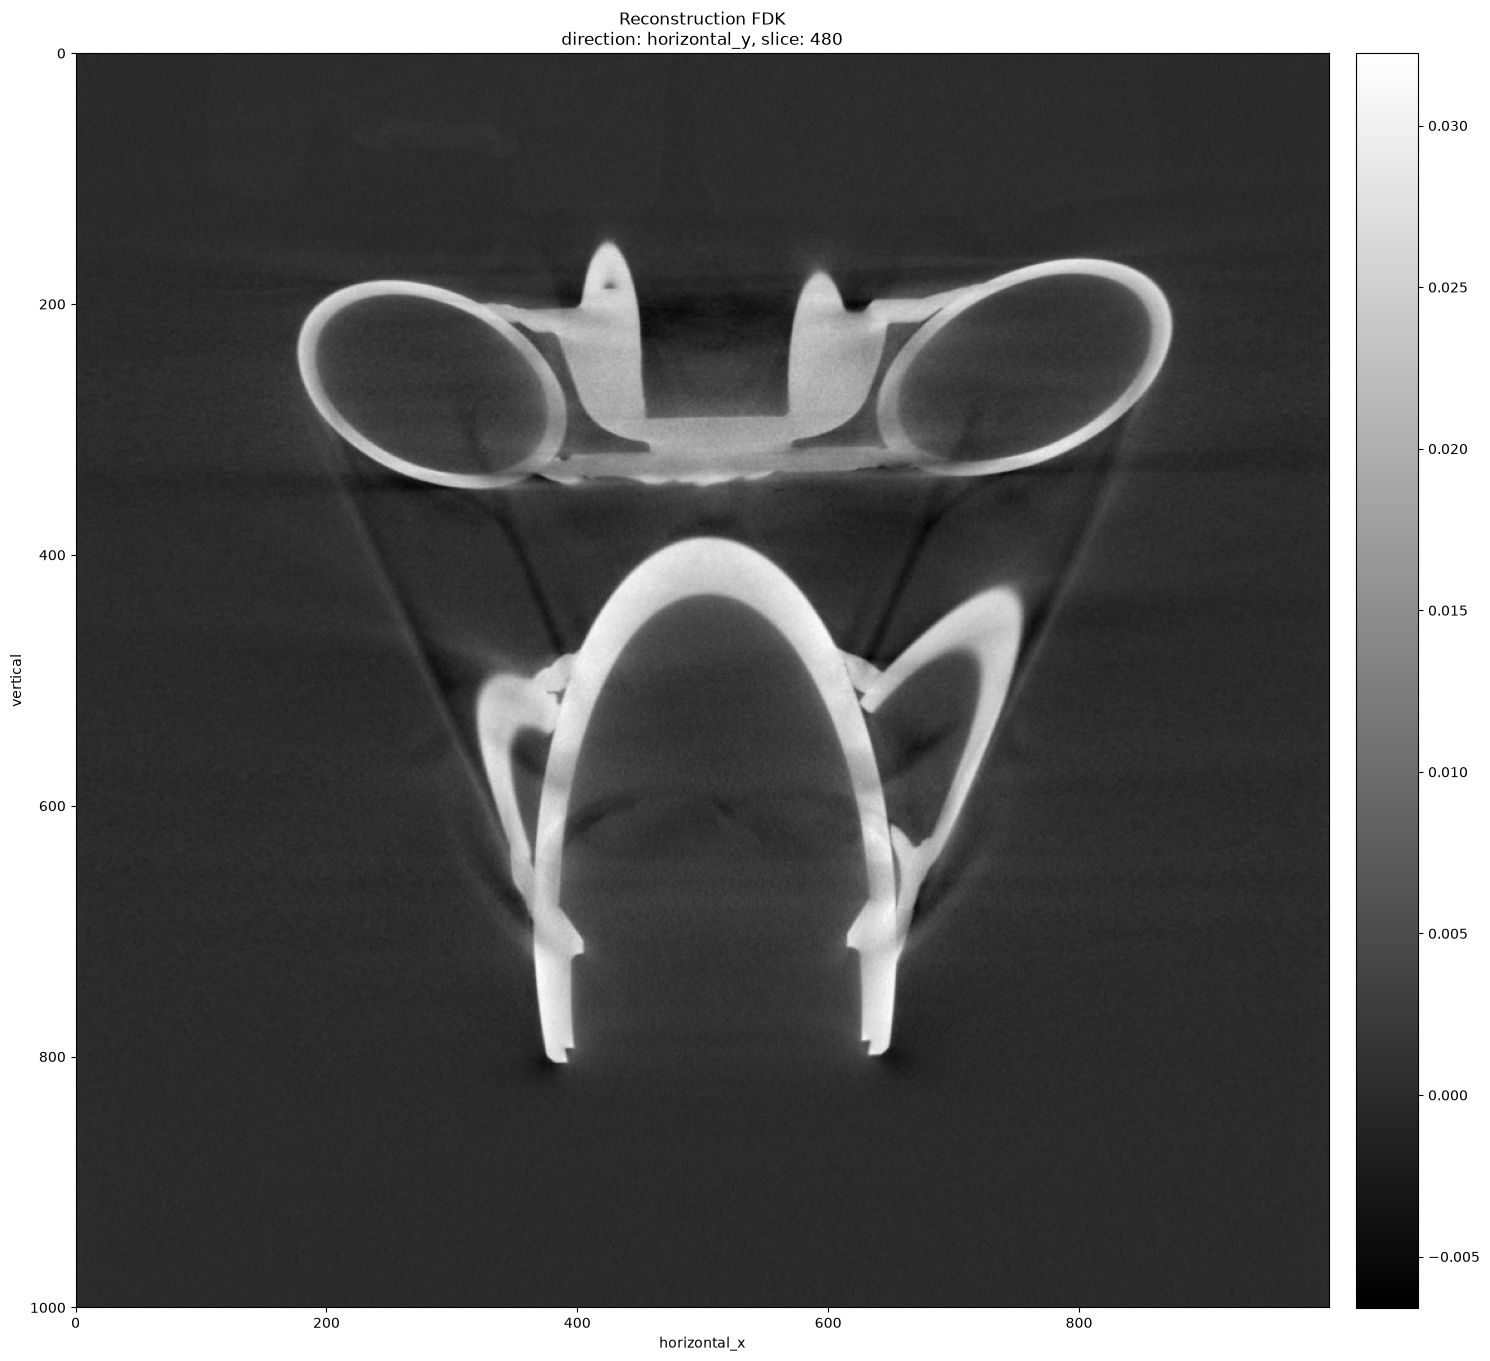

In [21]:
show2D(fdk_recon, slice_list=('horizontal_y', 480), title='Reconstruction FDK',  origin='upper-left')

We can also perform a model based image reconstruction with Total Variation regularization and a non-negativity constraint. We do this on binned data to save time:

In [ ]:
from cil.optimisation.functions import L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox
from cil.optimisation.operators import GradientOperator, BlockOperator
from cil.optimisation.algorithms import PDHG
from cil.plugins.tigre.ProjectionOperator import ProjectionOperator

In [23]:
roi = {'horizontal':(None, None, 4), 'vertical':(None, None, 4)}
reader = NikonDataReader(file_name=file_path, roi = roi)
data = reader.read()
data_exp = TransmissionAbsorptionConverter()(data)
data_exp.reorder('tigre')
acq_geom = reader.get_geometry()
img_geom = acq_geom.get_ImageGeometry()
A = ProjectionOperator(img_geom, acq_geom, device='gpu')
Grad = GradientOperator(img_geom)
K = BlockOperator(A, Grad)
alpha = 1.0
f1 = 0.5 * L2NormSquared(b=data_exp)
f2 = alpha * MixedL21Norm()
f = BlockFunction(f1, f2)
g = IndicatorBox(lower=0)


In [24]:
normK = K.norm()
sigma = 1./normK
tau = 1./normK


In [25]:
pdhg = PDHG(f=f, g=g, operator=K, sigma=sigma, tau=tau, update_objective_interval=5)
pdhg.run(40, verbose=2)

  0%|          | 0/40 [00:00<?, ?it/s]

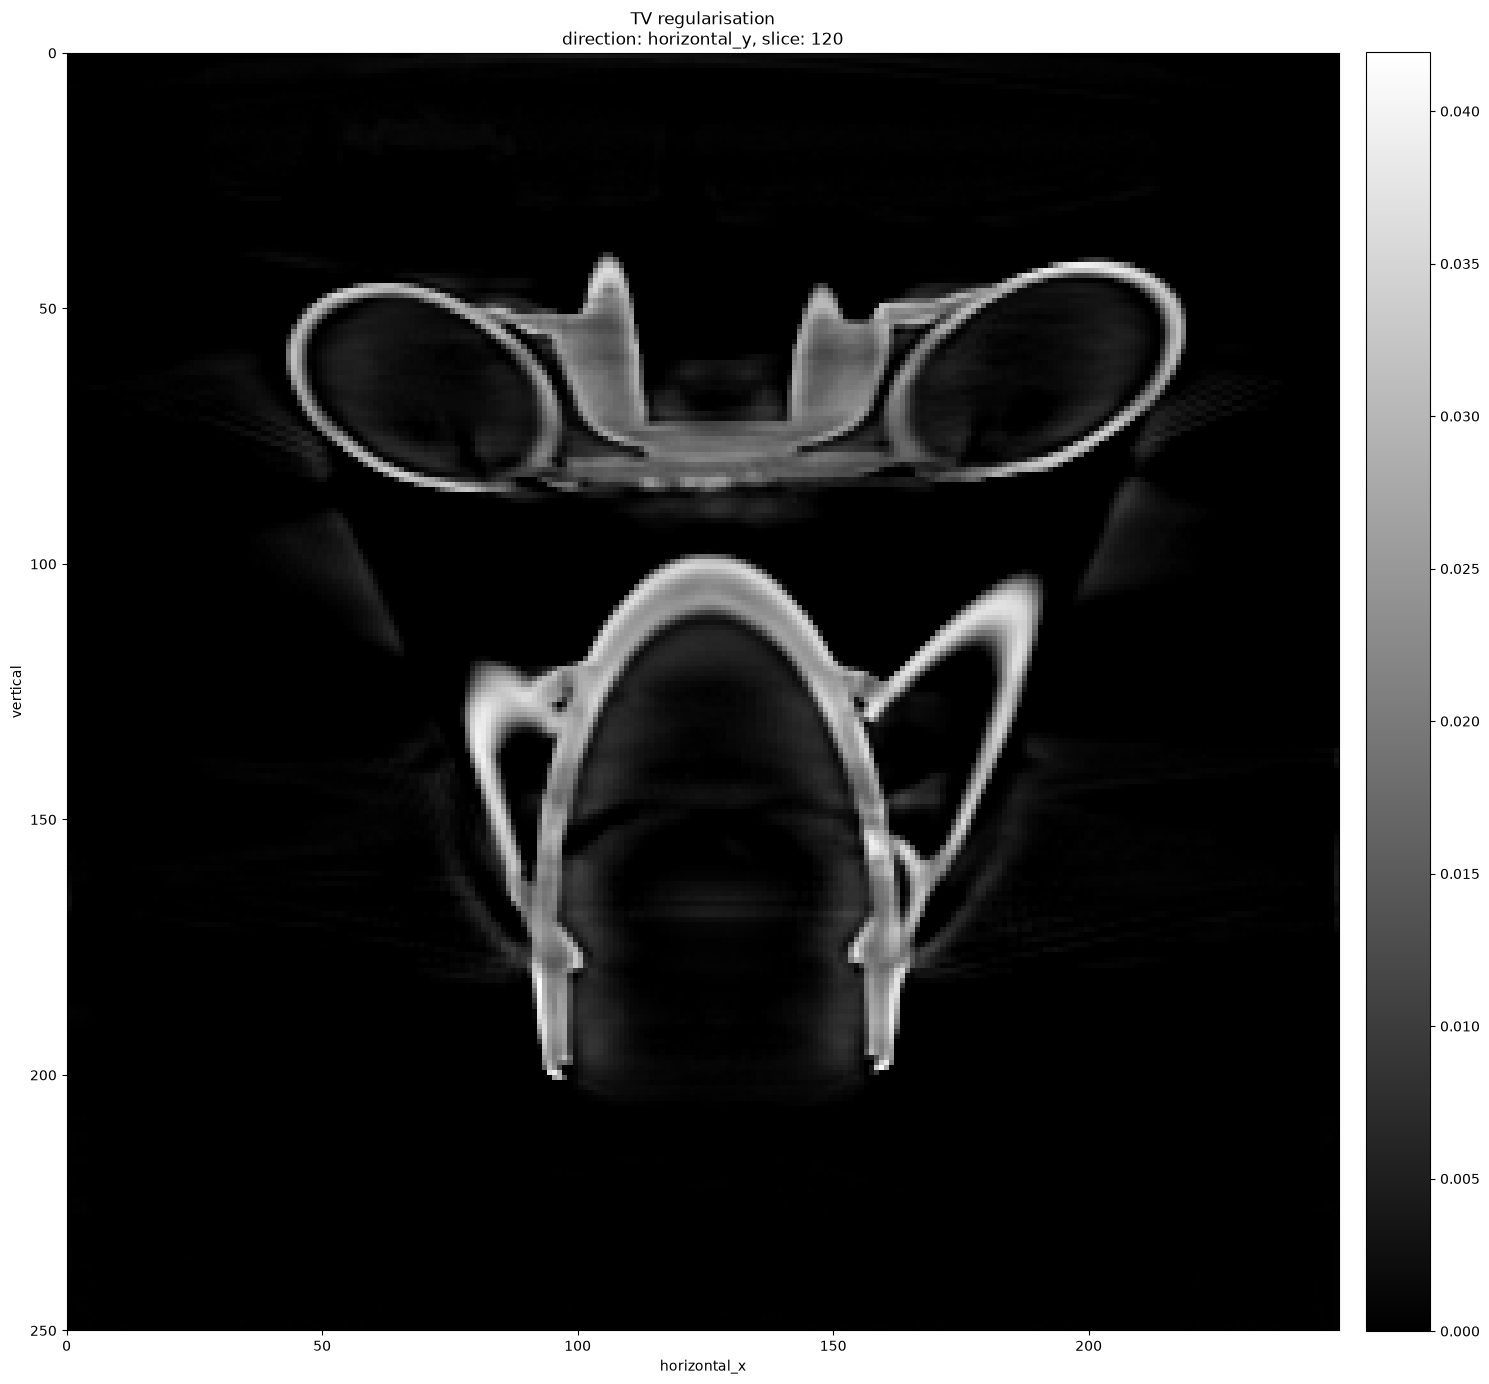

In [26]:
show2D(pdhg.solution,slice_list=('horizontal_y', 120), title='TV regularisation',  origin='upper-left')